从标准高斯分布中采样图片

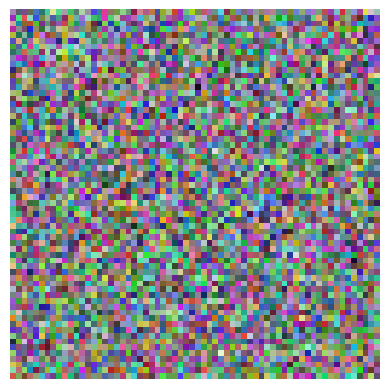

In [5]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple, Dict

x = torch.randn(3, 64, 64)

# 为了显示，把数值映射到 [0, 1]
x = torch.sigmoid(x)

plt.imshow(x.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [3]:
class LabeledSampleable(ABC):
    """
    Distribution which can be sampled from
    """
    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: b d
            - labels: b
        """
        pass


class GMM(nn.Module, LabeledSampleable):
  def __init__(self, means: torch.Tensor, covariances: torch.Tensor, weights: torch.Tensor):
    super().__init__()
    self.means = nn.Buffer(means)
    self.covariances = nn.Buffer(covariances)
    self.weights = nn.Buffer(weights)

  def sample(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Args:
      - num_samples: the desired number of samples
    Returns:
      - samples: b n
      - labels: b
    """
    # Choose the amount of each mode
    # Perform multinomial sampling on CPU to avoid device-side assert errors
    labels = torch.multinomial(self.weights.cpu(), num_samples=num_samples, replacement=True).to(self.means.device)

    # Sample from each mode
    samples = torch.zeros(num_samples, self.means.shape[1]).to(self.means.device)
    for idx in range(len(self.means)):
      samples[labels == idx] = torch.randn_like(samples[labels == idx]) * self.covariances[idx] + self.means[idx]

    return samples, labels

In [12]:
torch.manual_seed(19260817)
np.random.seed(19260817)

means = torch.tensor([
    [0.0, 0.0],   # 分量 0 的中心在原点
    [5.0, 5.0],   # 分量 1 的中心在 (5,5)
])

covariances = torch.tensor([
    [1.0, 1.0],   # 分量 0 的标准差（各维度独立）
    [0.5, 0.5],   # 分量 1 的标准差更小，更"紧凑"
])

weights = torch.tensor([0.7, 0.3])  # 70% 来自分量 0，30% 来自分量 1
num_samples = 10
labels = torch.multinomial(weights.cpu(), num_samples = num_samples, replacement=True)
samples = torch.zeros(num_samples, means.shape[1])
for idx in range(len(means)):
    samples[labels == idx] = torch.randn_like(samples[labels == idx]) * covariances[idx] + means[idx]

print(labels)
print(samples)



tensor([0, 0, 0, 0, 1, 1, 0, 1, 0, 1])
tensor([[ 1.4149, -0.5097],
        [-0.7814, -1.5098],
        [-0.7380,  1.2552],
        [ 1.4221,  2.2651],
        [ 5.8073,  5.2869],
        [ 5.2945,  5.3561],
        [-2.0694, -0.4391],
        [ 5.1795,  5.0837],
        [-0.7916,  0.7052],
        [ 4.8235,  4.9974]])


In [13]:
from torchvision import datasets, transforms

class MNISTSampler(nn.Module, LabeledSampleable):
    """
    Sampleable wrapper for the MNIST dataset
    """
    def __init__(self):
        super().__init__()
        self.dataset = datasets.MNIST(
            root='./data',
            train=True,
            download=True,
            transform=transforms.Compose([
                transforms.Resize((32, 32)),
                transforms.ToTensor(),
                transforms.Normalize((0.1305,), (0.2891,)),
            ])
        )
        self.dummy = nn.Buffer(torch.zeros(1)) # Will automatically be moved when self.to(...) is called...

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: shape (batch_size, c, h, w)
            - labels: shape (batch_size, label_dim)
        """
        if num_samples > len(self.dataset):
            raise ValueError(f"num_samples exceeds dataset size: {len(self.dataset)}")

        indices = torch.randperm(len(self.dataset))[:num_samples]
        samples, labels = zip(*[self.dataset[i] for i in indices])
        samples = torch.stack(samples).to(self.dummy)
        labels = torch.tensor(labels, dtype=torch.int64).to(self.dummy.device)
        return samples, labels

**Guidance**: Whereas for unconditional generation, we simply wanted to generate *any* digit, we would now like to be able to specify, or *condition*, on the identity of the digit we would like to generate. That is, we would like to be able to say "generate an image of the digit 8", rather than just "generate an image of a digit". We will henceforth refer to the digit we would like to generate as $x \in \mathbb{R}^{1 \times 32 \times 32}$, and the conditioning variable (in this case, a label), as $y \in \{0, 1, \dots, 9\}$. If we imagine fixing our choice of $y$, and take our data distribution as $p_{\text{simple}}(x|y)$, then we have recovered the unconditional generative problem, and we can construct a generative model using e.g., a conditional flow matching objective via $$\begin{align*}\mathcal{L}_{\text{CFM}}^{\text{guided}}(\theta;y) &= \,\,\mathbb{E}_{\square} \lVert u_t^{\theta}(x|y) - u_t^{\text{ref}}(x|z)\rVert^2\\ \square &= z \sim p_{\text{data}}(z|y), x \sim p_t(x|z)\end{align*}$$
We may now then allow $y$ to vary by simply taking our conditional flow matching expectation to be over $y$ as well (rather than fixing $y$), and explicitly conditioning our learned approximation on $u_t^{\theta}(x|y)$ on the choice of $y$. We therefore obtain the the *guided* conditional flow matching objective $$\begin{align*}\mathcal{L}_{\text{CFM}}(\theta) &= \,\,\mathbb{E}_{\square} \lVert u_t^{\theta}(x|y) - u_t^{\text{ref}}(x|z)\rVert^2\\ \square &= z,y \sim p_{\text{data}}(z,y), x \sim p_t(x|z)\end{align*}$$
Note that $(z,y) \sim p_{\text{simple}}(z,y)$ is obtained in practice by sampling an image $z$, and a label $y$, from our labelled (MNIST) dataset. This is all well and good, and we emphasize that if our goal was simply to sample from $p_{\text{data}}(x|y)$, our job would be done (at least in theory). In practice, one might argue that we care more about the *perceptual quality* of our images. To this end, we will a derive a procedure known as *classifier-free guidance*.

**无分类器引导**：为了直观理解，我们将通过高斯概率路径的视角来推导引导方法，尽管最终结果或许可以合理地应用于任何概率路径。回顾讲座内容，对于 $(a_t, b_t) = \left(\frac{\dot{\alpha}_t}{\alpha_t}, -\frac{\dot{\beta}_t \beta_t \alpha_t - \dot{\alpha}_t \beta_t^2}{\alpha_t}\right)$，我们有 $$u_t(x|y) = a_tx + b_t\nabla \log p_t(x|y).$$
这个恒等式让我们能把*条件边际速度* $u_t(x|y)$ 与*条件得分* $\nabla \log p_t(x|y)$ 联系起来。不过，请注意 $$\nabla \log p_t(x|y) = \nabla \log \left(\frac{p_t(x)p_t(y|x)}{p_t(y)}\right) = \nabla \log p_t(x) + \nabla \log p_t(y|x),$$
因此我们可以改写为 $$u_t(x|y) = a_tx + b_t(\nabla \log p_t(x) + \nabla \log p_t(y|x)) = u_t(x) + b_t \nabla \log p_t(y|x).$$
对 $\nabla \log p_t(y|x)$ 这一项的近似，可以被视为一种带噪声的分类器（事实上，这正是*分类器引导*的起源，但我们这里不讨论它）。在实践中，人们注意到，当我们缩放这个分类器项的贡献时，条件生成的效果似乎更好，于是得到
$$\tilde{u}_t(x|y) = u_t(x) + w b_t \nabla \log p_t(y|x)$$
其中 $w > 1$ 被称为*引导尺度*。然后我们可以代入 $b_t\log p_t(y|x) = u^{\text{target}}_t(x|y) - u^{\text{target}}_t(x)$，得到 $$\begin{align}\tilde{u}_t(x|y) &= u_t(x) + w b_t \nabla \log p_t(y|x)\\
&= u_t(x) + w (u^{\text{target}}_t(x|y) - u^{\text{target}}_t(x))\\
&= (1-w) u_t(x) + w u_t(x|y). \end{align}$$
因此，思路就是同时训练 $u_t(x)$ 和条件模型 $u_t(x|y)$，然后在*推理时*将它们组合起来，得到 $\tilde{u}_t(x|y)$。我们的步骤将是：
1. 使用条件流匹配训练 $u_t^{\theta} \approx u_t(x)$ 以及条件模型 $u_t^{\theta}(x|y) \approx u_t(x|y)$。
2. 在推理时，使用 $\tilde{u}_t^{\theta}(x|y)$ 进行采样。

“等等！”，你可能会说，“为什么非要训练两个模型呢？”确实，我们可以把 $u_t(x)$ 视为 $u_t(x|y)$ 的一种特殊情况，其中 $y=\varnothing$ 表示*没有条件*。这样，我们就可以在标签集合中加入一个新的额外标签 $\varnothing$，使得 $y \in \{0,1,\dots, 9, \varnothing\}$。这种技术被称为**无分类器引导**（CFG）。于是我们得到
$$\boxed{\tilde{u}_t(x|y) = (1-w) u_t(x|\varnothing) + w u_t(x|y)}.$$

**Classifier-Free Guidance**: For the sake of intuition, we will develop guidance through the lense of Gaussian probability paths, although the final result might reasonably be applied to any probability path. Recall from the lecture that for $(a_t, b_t) = \left(\frac{\dot{\alpha}_t}{\alpha_t}, -\frac{\dot{\beta}_t \beta_t \alpha_t - \dot{\alpha}_t \beta_t^2}{\alpha_t}\right)$, we have $$u_t(x|y) = a_tx + b_t\nabla \log p_t(x|y).$$
This identity allows us to relate the *conditional marginal velocity* $u_t(x|y)$ to the *conditional score* $\nabla \log p_t(x|y)$. However, notice that $$\nabla \log p_t(x|y) = \nabla \log \left(\frac{p_t(x)p_t(y|x)}{p_t(y)}\right) = \nabla \log p_t(x) + \nabla \log p_t(y|x),$$
so that we may rewrite $$u_t(x|y) = a_tx + b_t(\nabla \log p_t(x) + \nabla \log p_t(y|x)) = u_t(x) + b_t \nabla \log p_t(y|x).$$
An approximation of the term $\nabla \log p_t(y|x)$ could be considered as a sort of noisy classifier (and in fact this is the origin of *classifier guidance*, which we do not consider here). In practice, people have noticed that the conditioning seems to work better when we scale the contribution of this classifier term, yielding
$$\tilde{u}_t(x|y) = u_t(x) + w b_t \nabla \log p_t(y|x)$$
where $w > 1$ is known as the *guidance scale*. We may then plug in $b_t\log p_t(y|x) = u^{\text{target}}_t(x|y) - u^{\text{target}}_t(x)$ to obtain $$\begin{align}\tilde{u}_t(x|y) &= u_t(x) + w b_t \nabla \log p_t(y|x)\\
&= u_t(x) + w (u^{\text{target}}_t(x|y) - u^{\text{target}}_t(x))\\
&= (1-w) u_t(x) + w u_t(x|y). \end{align}$$
The idea is thus to train both $u_t(x)$ as well as the conditional model $u_t(x|y)$, and then combine them *at inference time* to obtain $\tilde{u}_t(x|y)$. Our recipe will thus be:
1. Train $u_t^{\theta} \approx u_t(x)$ as well as the conditional model $u_t^{\theta}(x|y) \approx u_t(x|y)$ using conditional flow matching.
2. At inference time, sample using $\tilde{u}_t^{\theta}(x|y)$.

"But wait!", you say, "why must we train two models?". Indeed, we can instead treat $u_t(x)$ as $u_t(x|y)$, where $y=\varnothing$ denotes *the absence of conditioning*. We may thus augment our label set with a new, additional $\varnothing$ label, so that $y \in \{0,1,\dots, 9, \varnothing\}$. This technique is known as **classifier-free guidance** (CFG). We thus arrive at
$$\boxed{\tilde{u}_t(x|y) = (1-w) u_t(x|\varnothing) + w u_t(x|y)}.$$

**训练与CFG**：我们现在必须修改我们的条件流匹配目标，以考虑 $y = \varnothing$ 的可能性。当然，当我们从MNIST中采样 $(z,y)$ 时，我们永远不会得到 $y = \varnothing$，所以我们必须人为地引入这种可能性。为此，我们将定义一个超参数 $\eta$ 作为我们丢弃原始标签 $y$ 并将其替换为 $\varnothing$ 的*概率*。在实践中，例如，我们可以设置 $\varnothing = 10$，因为它足以与其他数字身份区分开来。当我们去实现我们的模型时，我们只需要能够索引到某个嵌入，比如通过 `torch.nn.Embedding`。因此，我们得到了我们的CFG条件流匹配训练目标：
$$\begin{align*}\mathcal{L}_{\text{CFM}}(\theta) &= \,\,\mathbb{E}_{\square} \lVert u_t^{\theta}(x|y) - u_t^{\text{ref}}(x|z)\rVert^2\\
\square &= z,y \sim p_{\text{data}}(z,y), x \sim p_t(x|z),\,\text{以概率 $\eta$ 将 $y$ 替换为 $\varnothing$}\end{align*}$$
用大白话说，这个目标的意思是：
1. 从 $p_{\text{data}}$（这里是MNIST）中采样一个图像 $z$ 和一个标签 $y$。
2. 以概率 $\eta$，将标签 $y$ 替换为空标签 $\varnothing \triangleq 10$。
3. 从 $\mathcal{U}[0,1]$ 中采样 $t$。
4. 从条件概率路径 $p_t(x|z)$ 中采样 $x$。
5. 将 $u_t^{\theta}(x|y)$ 回归到 $u_t^{\text{ref}}(x|z)$。


**Training and CFG**: We must now amend our conditional flow matching objective to account for the possibility of $y = \varnothing$. Of course, when we sample $(z,y)$ from MNIST, we will never obtain $y = \varnothing$, so we must introduce the possibliity of this artificially. To do so, we will define some hyperparameter $\eta$ to be the *probability* that we discard the original label $y$, and replace it with $\varnothing$. In practice, we might set $\varnothing = 10$, for example, as it is sufficient to distinguish it from the other digit identities. When we go and implement our model, we need ony be able to index into some embedding, such as via `torch.nn.Embedding`. We thus arrive at our CFG conditional flow matching training objective:
$$\begin{align*}\mathcal{L}_{\text{CFM}}(\theta) &= \,\,\mathbb{E}_{\square} \lVert u_t^{\theta}(x|y) - u_t^{\text{ref}}(x|z)\rVert^2\\
\square &= z,y \sim p_{\text{data}}(z,y), x \sim p_t(x|z),\,\text{replace $y$ with $\varnothing$ with probability $\eta$}\end{align*}$$
In plain English, this objective reads:
1. Sample an image $z$ and a label $y$ from $p_{\text{data}}$ (here, MNIST).
2. With probability $\eta$, replace the label $y$ with the null label $\varnothing \triangleq 10$.
3. Sample $t$ from $\mathcal{U}[0,1]$.
4. Sample $x$ from the conditional probability path $p_t(x|z)$.
5. Regress $u_t^{\theta}(x|y)$ against $u_t^{\text{ref}}(x|z)$.


**Your job**: Fill in `CFGFlowTrainer.get_train_loss`, so that it implements $\mathcal{L}_{\text{CFM}}(\theta)$ described above. In doing so, feel free to "hardcode" $\varnothing = 10$. A more general implementation would not make this MNIST-specific assumption, but for the sake of this assignment you may do so. We recommend completing Question 2.2 and Question 2.3 together, as their combination can be tested in Sanity Check 2.4.

**Hints**:
1. To sample an image $(z,y) \sim p_{\text{data}}$, use `self.path.p_data.sample`
2. You can generate a mask corresponding to "probability $\eta$" via `mask = torch.rand(batch_size) < self.eta`.
3. You can sample $t \sim \mathcal{U}[0,1]$ using `torch.rand(batch_size, 1, 1, 1)`. Don't mix up `torch.rand` with `torch.randn`!
4. You can sample $x \sim p_t(x|z)$ using `self.path.sample_conditional_path`.

### Question 3.1: Fourier Time Encoder

First, we implement a *Fourier time encoder*, which maps a scalar time value $t \in [0,1]$ to
$$
    t^{\text{emb}} = \begin{bmatrix}
    \cos(2\pi w_1 t) & \cdots & \cos(2\pi w_d t) & \sin(2\pi w_1 t) & \cdots & \sin(2\pi w_d t)
    \end{bmatrix}^T,
$$
where the weights $w_i \sim \mathcal{N}(0, 1)$ are drawn from a unit normal.

**Your job**: Implement `FourierEncoder`.

In [21]:
w_i = torch.rand(1, 8)
t = torch.ones(4)
print(w_i.shape)
print(w_i)
print(t.shape)
print(t)
t = t.view(4, 1)
print(w_i * t)

torch.Size([1, 8])
tensor([[0.3356, 0.4909, 0.7982, 0.7535, 0.3889, 0.5888, 0.1711, 0.5089]])
torch.Size([4])
tensor([1., 1., 1., 1.])
tensor([[0.3356, 0.4909, 0.7982, 0.7535, 0.3889, 0.5888, 0.1711, 0.5089],
        [0.3356, 0.4909, 0.7982, 0.7535, 0.3889, 0.5888, 0.1711, 0.5089],
        [0.3356, 0.4909, 0.7982, 0.7535, 0.3889, 0.5888, 0.1711, 0.5089],
        [0.3356, 0.4909, 0.7982, 0.7535, 0.3889, 0.5888, 0.1711, 0.5089]])
